# Backtest Overfitting

## Overview

This notebook demonstrates the public functions in `backtest_overfitting` using a compact synthetic strategy return matrix.
- It computes annualized excess Sharpe ratios for strategy trials.
- It evaluates strategy selection through combinatorially symmetric cross-validation.
- It estimates the probability of backtest overfitting from out-of-sample ranks.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from src.model_backtesting.backtest_overfitting import (
    combinatorial_symmetric_cross_validation,
    get_sharpe_ratio_metric,
    probability_of_backtest_overfitting,
)

## Probability of Backtest Overfitting

This cell defines the example inputs for backtest-overfitting analysis.
- `returns` is the strategy return matrix, with observations in rows and strategies in columns.
- Stable-drift strategies provide persistent positive expected returns.
- Regime-dependent strategies perform better in the first half than in the second half.

,strategy_0,strategy_1,strategy_2,strategy_3,strategy_4,strategy_5,strategy_6,strategy_7
2024-01-02,0.002271,-0.003980,0.004877,0.005433,-0.008330,-0.005360,0.000875,-0.001123
2024-01-03,0.000824,-0.003139,0.005457,0.004700,0.000747,0.005573,0.002404,-0.003567
2024-01-04,0.002559,-0.003615,0.005453,0.000975,-0.000382,-0.002564,0.005801,-0.000395
2024-01-05,-0.001027,-0.000885,0.003895,0.002844,0.002307,0.002439,0.009937,-0.001529
2024-01-08,-0.001405,-0.002962,0.004272,0.006280,-0.000063,-0.003281,-0.003410,0.003228


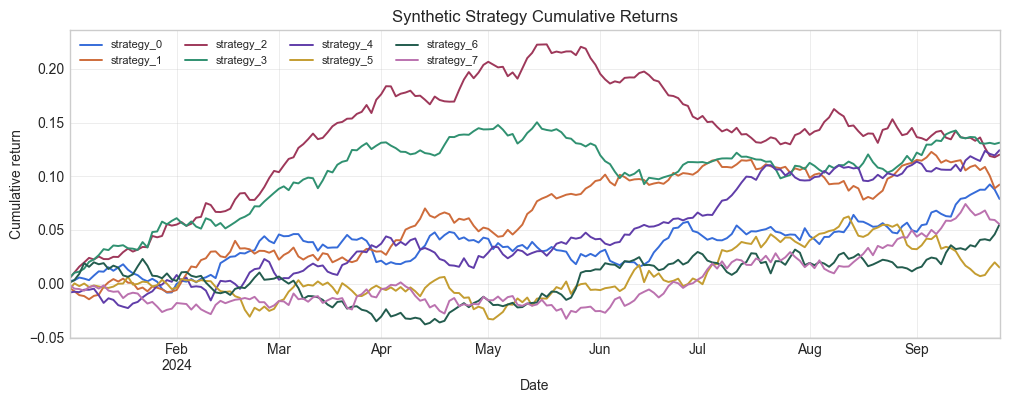

In [3]:
rng = np.random.default_rng(42)
dates = pd.bdate_range("2024-01-02", periods=192)

base_noise = rng.normal(0, 0.0045, size=(len(dates), 8))
returns = pd.DataFrame(
    base_noise,
    index=dates,
    columns=[f"strategy_{i}" for i in range(8)],
)

returns["strategy_0"] += 0.0009
returns["strategy_1"] += 0.0007
returns.loc[dates[:96], "strategy_2"] += 0.0015
returns.loc[dates[96:], "strategy_2"] -= 0.0001
returns.loc[dates[:96], "strategy_3"] += 0.0012
returns.loc[dates[96:], "strategy_3"] -= 0.0002
returns["strategy_4"] += 0.00045
returns["strategy_5"] += 0.00050
returns["strategy_6"] += 0.00030
returns["strategy_7"] += 0.00030

display(returns.head())

fig, ax = plt.subplots(figsize=(12, 4))
returns.cumsum().plot(ax=ax, linewidth=1.4)
ax.set_title("Synthetic Strategy Cumulative Returns")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
ax.legend(ncol=4, fontsize=8)
plt.show()

This cell defines the Sharpe ratio metric used for strategy selection.
- `annual_risk_free_rate` is the annual return subtracted from strategy returns after conversion to a per-period rate.
- `periods_per_year` annualizes the per-period Sharpe ratio.
- `metric_func` returns annualized excess Sharpe ratios for each strategy column.

In [4]:
annual_risk_free_rate = 0.02
periods_per_year = 252

metric_func = get_sharpe_ratio_metric(
    annual_risk_free_rate=annual_risk_free_rate,
    periods_per_year=periods_per_year,
)

full_sample_sharpe = metric_func(returns).sort_values(ascending=False)
display(full_sample_sharpe.to_frame("annualized_excess_sharpe"))

,annualized_excess_sharpe
strategy_3,2.238901
strategy_4,2.095932
strategy_2,1.723271
strategy_1,1.444102
strategy_0,1.180926
strategy_7,0.738503
strategy_6,0.737317
strategy_5,-0.003282


This cell computes the CSCV results for the strategy return matrix.
- `num_partitions` controls how many equal row blocks are formed.
- `best_strategy` is the strategy with the highest in-sample metric in each split.
- `is_metric` is the in-sample Sharpe ratio of the selected strategy.
- `oos_metric` is the out-of-sample Sharpe ratio of the selected strategy.
- `relative_rank` is the selected strategy's out-of-sample rank scaled into `(0, 1)`.
- `logit` transforms `relative_rank` into log-odds, where values below zero indicate below median OOS performance.

In [5]:
num_partitions = 12
cscv = combinatorial_symmetric_cross_validation(
    returns=returns,
    num_partitions=num_partitions,
    metric_func=metric_func,
)

display(cscv.head())
print(f"Number of CSCV splits: {len(cscv):,}")

,train_partitions,test_partitions,best_strategy,is_metric,oos_metric,relative_rank,logit
0,"(0, 1, 2, 3, 4, 5)","(6, 7, 8, 9, 10, 11)",strategy_2,7.179303,-3.542002,0.111111,-2.079442
1,"(0, 1, 2, 3, 4, 6)","(5, 7, 8, 9, 10, 11)",strategy_2,4.635760,-0.911523,0.111111,-2.079442
2,"(0, 1, 2, 3, 4, 7)","(5, 6, 8, 9, 10, 11)",strategy_2,5.229306,-1.107985,0.111111,-2.079442
3,"(0, 1, 2, 3, 4, 8)","(5, 6, 7, 9, 10, 11)",strategy_3,5.327704,-0.489101,0.333333,-0.693147
4,"(0, 1, 2, 3, 4, 9)","(5, 6, 7, 8, 10, 11)",strategy_2,6.873511,-2.519026,0.111111,-2.079442


Number of CSCV splits: 924


This cell computes the probability of backtest overfitting from CSCV logits.
- `pbo` is the fraction of splits where the selected strategy ranks at or below the out-of-sample median.
- A PBO around 82% indicates that the in-sample winner usually underperforms out-of-sample, suggesting a high risk of backtest overfitting.

In [6]:
pbo = probability_of_backtest_overfitting(
    returns=returns,
    num_partitions=num_partitions,
    metric_func=metric_func,
)

print(f"PBO: {pbo:.2%}")

PBO: 82.47%


This cell visualizes the backtest-overfitting results.
- The logit histogram shows the empirical distribution of out-of-sample ranks.
- In this example, most logits fall below zero, so the in-sample winners usually rank below the out-of-sample median.
- The scatter plot compares in-sample and out-of-sample Sharpe ratios for the selected strategies.
- The selected strategies show much stronger in-sample Sharpe ratios than out-of-sample Sharpe ratios, indicating persistent performance decay from backtest overfitting.

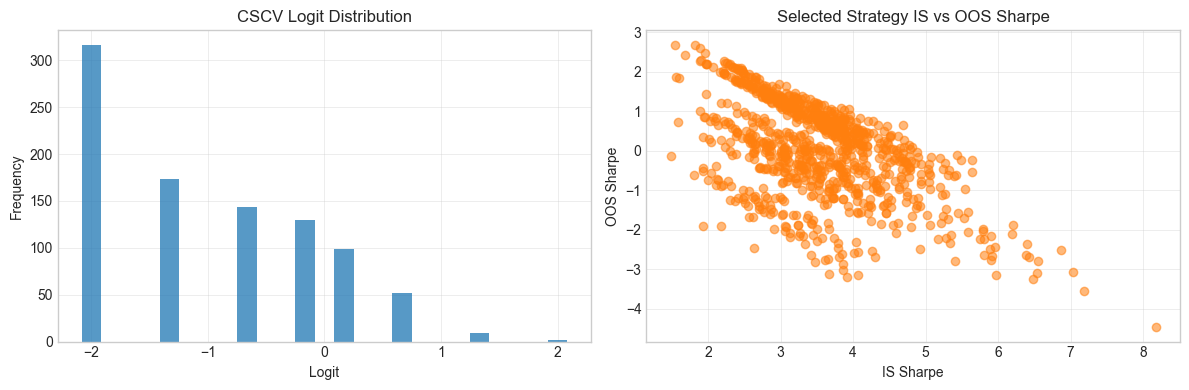

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cscv["logit"], bins=25, color="tab:blue", alpha=0.75)
axes[0].set_title("CSCV Logit Distribution")
axes[0].set_xlabel("Logit")
axes[0].set_ylabel("Frequency")

axes[1].scatter(cscv["is_metric"], cscv["oos_metric"], alpha=0.55, color="tab:orange")
axes[1].set_title("Selected Strategy IS vs OOS Sharpe")
axes[1].set_xlabel("IS Sharpe")
axes[1].set_ylabel("OOS Sharpe")

plt.tight_layout()
plt.show()